# Entrenamiento: Auto-Annotator (YOLO OBB)

Notebook para entrenar un modelo auxiliar YOLOv8n-OBB sobre el dataset semilla (300 imágenes) y generar pre-anotaciones OBB para las imágenes restantes.

**Propósito**: El auto-annotator acelera el etiquetado manual en CVAT. No es un modelo de producción.

## Flujo

1. Entrenar YOLOv8n-OBB con `data/obb-seed/` (300 imgs anotadas manualmente)
2. Evaluar en split de validación (80/20)
3. Pre-anotar automáticamente las ~900 imágenes válidas restantes
4. Exportar anotaciones para revisión en CVAT

---

## PARTE 1: CONFIGURACIÓN DEL ENTORNO

### 1.1 Verificar GPU disponible

In [1]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("ADVERTENCIA: No se detecto GPU. Ve a Runtime > Change runtime type > GPU")

PyTorch version: 2.10.0+cu128
CUDA disponible: True
GPU: Tesla T4
CUDA version: 12.8


### 1.2 Instalar Ultralytics

In [2]:
!pip install -q ultralytics

from ultralytics import YOLO
import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.16


### 1.3 Montar Google Drive

**IMPORTANTE:** Antes de ejecutar, sube los datos a Google Drive.

Estructura esperada en Drive:
```
MyDrive/water-meter-training/
├── data/
│   ├── obb-seed/                      # 300 imgs anotadas (= data/obb-seed/ del repo)
│   │   ├── images/train/
│   │   ├── labels/train/
│   │   └── data.yaml
│   └── valid-samples/                 # ~900 imgs válidas sin anotar
│
└── auto-annotator/                    # Generado por este notebook
    ├── dataset/                       # Copia local con split train/val
    ├── runs/                          # YOLO output
    └── auto-annotated/                # Labels + previews generados
        ├── labels/
        └── previews/
```

In [3]:
from google.colab import drive
import os

drive.mount('/content/drive', force_remount=True)

DRIVE_MOUNT_PATH = '/content/drive/MyDrive/water-meter-training'

if os.path.exists(f'{DRIVE_MOUNT_PATH}/data/obb-seed'):
    print(f"Dataset obb-seed encontrado en: {DRIVE_MOUNT_PATH}/data/obb-seed")
else:
    print(f"ADVERTENCIA: No se encontro data/obb-seed/ en {DRIVE_MOUNT_PATH}")
    print("Sube data/obb-seed/ a Drive antes de continuar")

Mounted at /content/drive
Dataset obb-seed encontrado en: /content/drive/MyDrive/water-meter-training/data/obb-seed


### 1.4 Configuración de Rutas del Proyecto

In [4]:
# =====================================================
# CONFIGURACION DE RUTAS
# =====================================================

DRIVE_BASE = '/content/drive/MyDrive/water-meter-training'

# Datos de entrada
SOURCE_DATASET_PATH = f'{DRIVE_BASE}/data/obb-seed'
VALID_IMAGES_PATH = f'{DRIVE_BASE}/data/valid-samples'

# Componente: auto-annotator
COMPONENT_DIR = f'{DRIVE_BASE}/auto-annotator'
RESULTS_DIR = f'{COMPONENT_DIR}/runs'
DATASET_PATH = f'{COMPONENT_DIR}/dataset'
AUTO_LABELS_DIR = f'{COMPONENT_DIR}/auto-annotated'

# Rutas derivadas (no modificar)
TRAIN_IMAGES = f'{DATASET_PATH}/images/train'
TRAIN_LABELS = f'{DATASET_PATH}/labels/train'
VAL_IMAGES = f'{DATASET_PATH}/images/val'
VAL_LABELS = f'{DATASET_PATH}/labels/val'
DATA_YAML = f'{DATASET_PATH}/data.yaml'

os.makedirs(COMPONENT_DIR, exist_ok=True)

print("=== CONFIGURACION DE RUTAS ===")
print(f"Dataset fuente:  {SOURCE_DATASET_PATH}")
print(f"Imgs válidas:    {VALID_IMAGES_PATH}")
print(f"Componente:      {COMPONENT_DIR}")
print(f"  dataset/       {DATASET_PATH}")
print(f"  runs/          {RESULTS_DIR}")
print(f"  auto-annotated/{AUTO_LABELS_DIR}")

=== CONFIGURACION DE RUTAS ===
Dataset fuente:  /content/drive/MyDrive/water-meter-training/data/obb-seed
Imgs válidas:    /content/drive/MyDrive/water-meter-training/data/valid-samples
Componente:      /content/drive/MyDrive/water-meter-training/auto-annotator
  dataset/       /content/drive/MyDrive/water-meter-training/auto-annotator/dataset
  runs/          /content/drive/MyDrive/water-meter-training/auto-annotator/runs
  auto-annotated//content/drive/MyDrive/water-meter-training/auto-annotator/auto-annotated


### 1.5 Importar bibliotecas necesarias

In [5]:
import os
import glob
import shutil
import random
import zipfile
from pathlib import Path
from datetime import datetime
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

IMG_EXTS = ('.jpg', '.jpeg', '.png')

def count_images(directory):
    """Cuenta imágenes en un directorio."""
    return len([f for f in os.listdir(directory) if f.lower().endswith(IMG_EXTS)])

print("Bibliotecas importadas correctamente")

Bibliotecas importadas correctamente


---

## PARTE 2: PREPARACIÓN DEL DATASET

### 2.1 Copiar Dataset y Crear Split Train/Val

El dataset `obb-seed/` solo tiene `train/` (300 imgs). Se copia al workspace y se hace un split 80/20 para validación.

In [6]:
# Verificar si necesita copia + split
needs_copy = not os.path.exists(DATASET_PATH) or not os.path.exists(TRAIN_IMAGES)

# Verificar que las imágenes realmente estén copiadas (no solo labels)
if not needs_copy:
    has_train = os.path.exists(TRAIN_IMAGES) and count_images(TRAIN_IMAGES) > 0
    has_val = os.path.exists(VAL_IMAGES) and count_images(VAL_IMAGES) > 0
    if not has_train or not has_val:
        needs_copy = True
        print("Dataset incompleto detectado, re-copiando...")

if needs_copy:
    if not os.path.exists(f'{SOURCE_DATASET_PATH}/images/train'):
        raise FileNotFoundError(f"Dataset fuente no encontrado: {SOURCE_DATASET_PATH}")

    # Limpiar destino si existe parcialmente
    if os.path.exists(DATASET_PATH):
        shutil.rmtree(DATASET_PATH)

    # Copiar obb-seed completo al workspace
    print(f"Copiando {SOURCE_DATASET_PATH} → {DATASET_PATH} ...")
    shutil.copytree(SOURCE_DATASET_PATH, DATASET_PATH)
    print("Copia completada")

    # Crear split: mover 20% de train/ a val/
    os.makedirs(VAL_IMAGES, exist_ok=True)
    os.makedirs(VAL_LABELS, exist_ok=True)

    all_images = sorted([f for f in os.listdir(TRAIN_IMAGES) if f.lower().endswith(IMG_EXTS)])
    random.shuffle(all_images)

    split_idx = int(len(all_images) * 0.8)
    val_images = all_images[split_idx:]

    for img_name in val_images:
        label_name = os.path.splitext(img_name)[0] + '.txt'
        shutil.move(f'{TRAIN_IMAGES}/{img_name}', f'{VAL_IMAGES}/{img_name}')
        if os.path.exists(f'{TRAIN_LABELS}/{label_name}'):
            shutil.move(f'{TRAIN_LABELS}/{label_name}', f'{VAL_LABELS}/{label_name}')

    print(f"Split completado: {len(val_images)} imgs movidas a val/")
else:
    print("Dataset ya existe en workspace, omitiendo copia")

# Verificar
n_train = count_images(TRAIN_IMAGES)
n_val = count_images(VAL_IMAGES)
n_train_lbl = len([f for f in os.listdir(TRAIN_LABELS) if f.endswith('.txt')])
n_val_lbl = len([f for f in os.listdir(VAL_LABELS) if f.endswith('.txt')])

print(f"\n=== DATASET EN WORKSPACE ===")
print(f"  train: {n_train} images, {n_train_lbl} labels")
print(f"  val:   {n_val} images, {n_val_lbl} labels")
print(f"  Total: {n_train + n_val}")

assert n_train == n_train_lbl, f"Mismatch train: {n_train} imgs vs {n_train_lbl} labels"
assert n_val == n_val_lbl, f"Mismatch val: {n_val} imgs vs {n_val_lbl} labels"

Copiando /content/drive/MyDrive/water-meter-training/data/obb-seed → /content/drive/MyDrive/water-meter-training/auto-annotator/dataset ...
Copia completada
Split completado: 60 imgs movidas a val/

=== DATASET EN WORKSPACE ===
  train: 240 images, 240 labels
  val:   60 images, 60 labels
  Total: 300


### 2.2 Generar data.yaml

In [7]:
data_config = {
    'path': DATASET_PATH,
    'train': 'images/train',
    'val': 'images/val',
    'names': {0: 'Odometer'},
    'nc': 1,
}

with open(DATA_YAML, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print("data.yaml generado:")
print(yaml.dump(data_config, default_flow_style=False))

data.yaml generado:
names:
  0: Odometer
nc: 1
path: /content/drive/MyDrive/water-meter-training/auto-annotator/dataset
train: images/train
val: images/val



---

## PARTE 3: CONFIGURACIÓN DEL MODELO

### 3.1 Modelo e Hiperparámetros

In [8]:
# =====================================================
# MODELO E HIPERPARAMETROS
# =====================================================

MODEL_NAME = 'yolov8n-obb.pt'  # Nano — suficiente para pre-anotación

EPOCHS = 100
IMG_SIZE = 640
BATCH_SIZE = 16
PATIENCE = 20

model = YOLO(MODEL_NAME)

print(f"Modelo: {MODEL_NAME}")
print(f"Epochs: {EPOCHS}, Img size: {IMG_SIZE}, Batch: {BATCH_SIZE}, Patience: {PATIENCE}")
print(f"Dispositivo: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

Modelo: yolov8n-obb.pt
Epochs: 100, Img size: 640, Batch: 16, Patience: 20
Dispositivo: CUDA


---

## PARTE 4: ENTRENAMIENTO

### 4.1 Ejecutar Entrenamiento

Puede tomar 30-60 min dependiendo de la GPU.

In [9]:
print("Iniciando entrenamiento: auto-annotator")
print(f"Resultados en: {RESULTS_DIR}/auto-annotator")
print("=" * 50)

results = model.train(
    data=DATA_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    patience=PATIENCE,
    device=0 if torch.cuda.is_available() else 'cpu',
    project=RESULTS_DIR,
    name='auto-annotator',
    exist_ok=True,

    # Augmentaciones
    degrees=15.0,
    translate=0.1,
    scale=0.2,
    flipud=0.0,       # No flip vertical (odómetros tienen orientación)
    fliplr=0.5,

    amp=True,
    save=True,
    save_period=10,
    plots=True,
    verbose=True,
)

print("\n" + "=" * 50)
print("Entrenamiento completado!")
print(f"Mejor modelo: {results.save_dir}/weights/best.pt")

Iniciando entrenamiento: auto-annotator
Resultados en: /content/drive/MyDrive/water-meter-training/auto-annotator/runs/auto-annotator
Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/water-meter-training/auto-annotator/dataset/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, mod

---

## PARTE 5: RESULTADOS Y EVALUACIÓN

### 5.1 Cargar Mejor Modelo

In [10]:
RUN_PATH = f'{RESULTS_DIR}/auto-annotator'

if os.path.exists(RUN_PATH):
    print(f"Corrida encontrada: {RUN_PATH}")
else:
    print(f"ERROR: No se encontro la corrida en {RUN_PATH}")
    RUN_PATH = None

Corrida encontrada: /content/drive/MyDrive/water-meter-training/auto-annotator/runs/auto-annotator


In [11]:
if RUN_PATH:
    best_model_path = f'{RUN_PATH}/weights/best.pt'
    if os.path.exists(best_model_path):
        model_best = YOLO(best_model_path)
        print(f"Modelo cargado desde: {best_model_path}")
    else:
        print(f"ERROR: No se encontro best.pt en {RUN_PATH}/weights/")
        model_best = None
else:
    model_best = None

Modelo cargado desde: /content/drive/MyDrive/water-meter-training/auto-annotator/runs/auto-annotator/weights/best.pt


### 5.2 Métricas de Validación

In [12]:
if model_best:
    metrics = model_best.val(
        data=DATA_YAML,
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        device=0 if torch.cuda.is_available() else 'cpu',
        plots=True,
    )

    print("\n" + "=" * 50)
    print("=== METRICAS DE VALIDACION ===")
    print("=" * 50)
    print(f"  mAP50-95:  {metrics.box.map:.4f}  ← metrica principal")
    print(f"  mAP50:     {metrics.box.map50:.4f}")
    print(f"  Precision: {metrics.box.mp:.4f}")
    print(f"  Recall:    {metrics.box.mr:.4f}")
    print("=" * 50)
else:
    print("No hay modelo cargado para validar")

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-obb summary (fused): 82 layers, 3,077,414 parameters, 0 gradients, 8.3 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 80.5±13.5 MB/s, size: 192.6 KB)
val: Scanning /content/drive/MyDrive/water-meter-training/auto-annotator/dataset/labels/val.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 22.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.4it/s 2.9s
                   all         60         60          1          1      0.995      0.952
Speed: 8.4ms preprocess, 12.4ms inference, 0.0ms loss, 9.4ms postprocess per image
Results saved to /content/runs/obb/val

=== METRICAS DE VALIDACION ===
  mAP50-95:  0.9520  ← metrica principal
  mAP50:     0.9950
  Precision: 1.0000
  Recall:    1.0000


### 5.3 Curvas de Entrenamiento

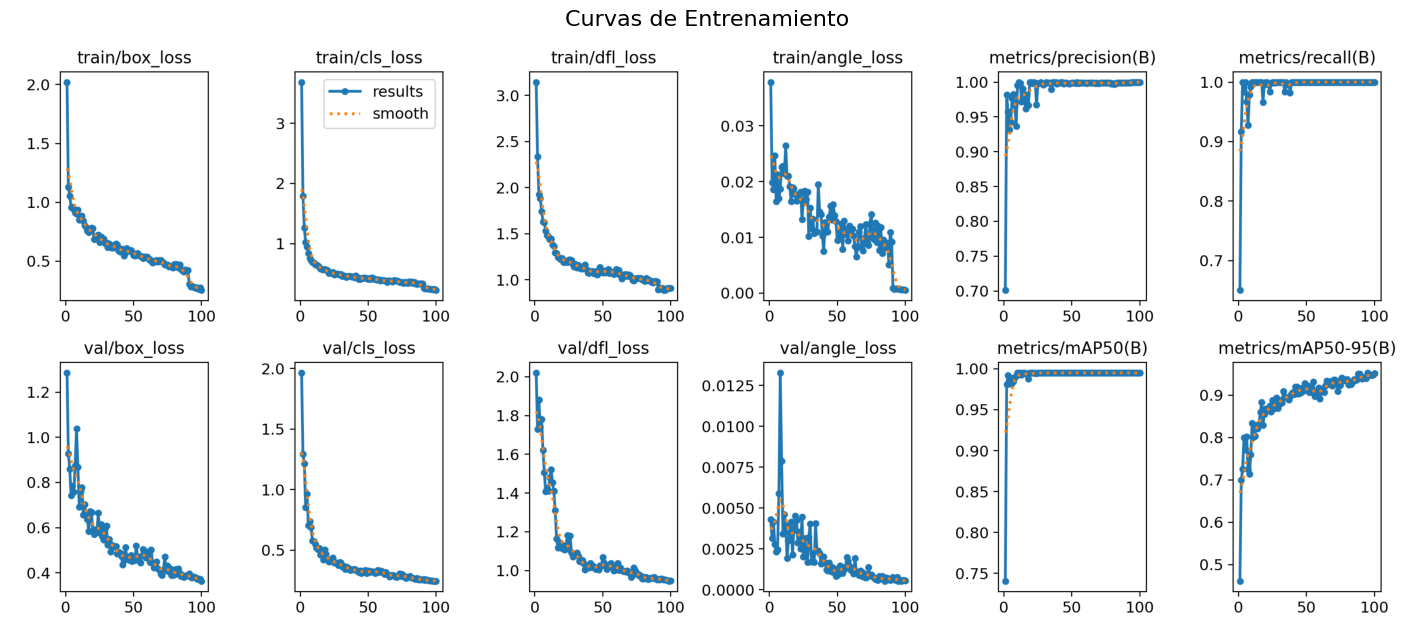

In [13]:
if RUN_PATH:
    results_img = f'{RUN_PATH}/results.png'
    if os.path.exists(results_img):
        plt.figure(figsize=(18, 12))
        plt.imshow(Image.open(results_img))
        plt.axis('off')
        plt.title('Curvas de Entrenamiento', fontsize=16)
        plt.show()
    else:
        print(f"No se encontro results.png en {RUN_PATH}")

### 5.4 Predicciones en Validación (sample)

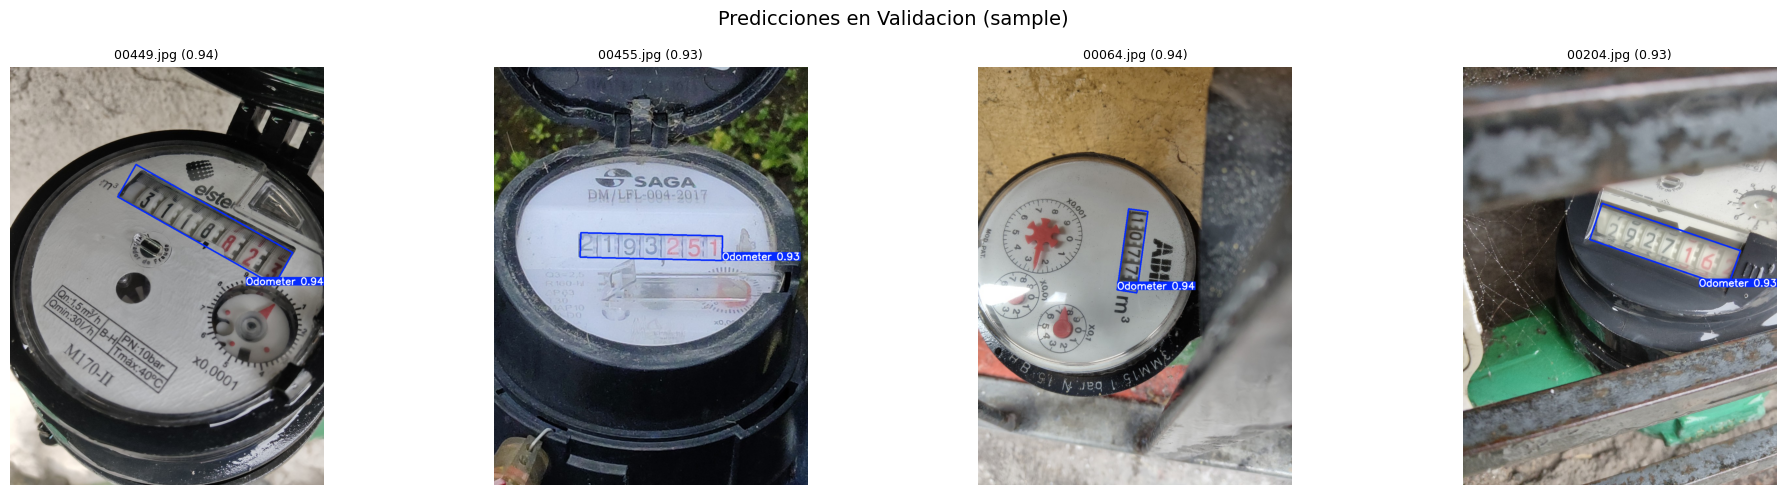

In [14]:
if model_best and os.path.exists(VAL_IMAGES):
    val_files = [f for f in os.listdir(VAL_IMAGES) if f.lower().endswith(IMG_EXTS)]
    sample_val = random.sample(val_files, min(4, len(val_files)))

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for idx, img_name in enumerate(sample_val):
        img_path = f'{VAL_IMAGES}/{img_name}'
        results = model_best.predict(img_path, conf=0.25, verbose=False)

        img_result = results[0].plot()
        img_result = cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB)

        if len(results[0].obb) > 0 and results[0].obb.conf is not None:
            conf = results[0].obb.conf[0].item()
            title = f'{img_name} ({conf:.2f})'
        else:
            title = f'{img_name} (sin det.)'

        axes[idx].imshow(img_result)
        axes[idx].set_title(title, fontsize=9)
        axes[idx].axis('off')

    plt.suptitle('Predicciones en Validacion (sample)', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No hay modelo o imagenes de validacion disponibles")

---

## PARTE 6: PRE-ANOTACIÓN AUTOMÁTICA

### 6.1 Identificar Imágenes Sin Anotar

In [28]:
if os.path.exists(VALID_IMAGES_PATH):
    all_valid = [f for f in os.listdir(VALID_IMAGES_PATH) if f.lower().endswith(IMG_EXTS)]

    # Excluir imágenes que ya tienen anotación (están en el dataset seed)
    annotated = set()
    for split_dir in [TRAIN_IMAGES, VAL_IMAGES]:
        if os.path.exists(split_dir):
            annotated.update(f for f in os.listdir(split_dir) if f.lower().endswith(IMG_EXTS))

    unannotated = [img for img in all_valid if img not in annotated]

    print(f"Total imagenes validas:  {len(all_valid)}")
    print(f"Ya anotadas (seed):      {len(annotated)}")
    print(f"Por anotar:              {len(unannotated)}")
else:
    print(f"ADVERTENCIA: No se encontro {VALID_IMAGES_PATH}")
    unannotated = []

Total imagenes validas:  1199
Ya anotadas (seed):      300
Por anotar:              899


### 6.2 Ejecutar Inferencia

Umbral de confianza bajo (0.25) para capturar todas las detecciones posibles. Las anotaciones se revisarán manualmente en CVAT.

In [29]:
CONFIDENCE_THRESHOLD = 0.25
IOU_THRESHOLD = 0.45

# Crear estructura de salida
AUTO_LABELS_PATH = f'{AUTO_LABELS_DIR}/labels'
AUTO_VIZ_PATH = f'{AUTO_LABELS_DIR}/previews'
os.makedirs(AUTO_LABELS_PATH, exist_ok=True)
os.makedirs(AUTO_VIZ_PATH, exist_ok=True)

# Contadores
images_processed = 0
images_with_detections = 0
total_detections = 0
all_confidences = []

print(f"Procesando {len(unannotated)} imagenes (conf={CONFIDENCE_THRESHOLD})...")

for img_name in tqdm(unannotated):
    img_path = f'{VALID_IMAGES_PATH}/{img_name}'
    if not os.path.exists(img_path):
        continue

    results = model_best.predict(img_path, conf=CONFIDENCE_THRESHOLD, iou=IOU_THRESHOLD, verbose=False)
    images_processed += 1

    if len(results[0].obb) == 0:
        continue

    images_with_detections += 1

    # Confidencias
    if results[0].obb.conf is not None:
        all_confidences.extend(results[0].obb.conf.cpu().numpy().flatten().tolist())

    # Guardar label YOLO OBB
    label_name = os.path.splitext(img_name)[0] + '.txt'
    with open(f'{AUTO_LABELS_PATH}/{label_name}', 'w') as f:
        for detection in results[0].obb:
            coords = detection.xyxyxyxyn[0].cpu().numpy().flatten()
            line = '0 ' + ' '.join(f'{c:.6f}' for c in coords)
            f.write(line + '\n')
            total_detections += 1

    # Guardar preview
    viz_img = results[0].plot()
    cv2.imwrite(f'{AUTO_VIZ_PATH}/{os.path.splitext(img_name)[0]}_annotated.jpg', viz_img)

print(f"\n=== RESUMEN DE PRE-ANOTACION ===")
print(f"Imagenes procesadas:       {images_processed}")
print(f"Con detecciones:           {images_with_detections}")
print(f"Sin detecciones:           {images_processed - images_with_detections}")
print(f"Total detecciones OBB:     {total_detections}")
if all_confidences:
    print(f"Confianza: min={min(all_confidences):.3f}, max={max(all_confidences):.3f}, media={np.mean(all_confidences):.3f}")
print(f"\nLabels en: {AUTO_LABELS_PATH}")
print(f"Previews en: {AUTO_VIZ_PATH}")

Procesando 899 imagenes (conf=0.25)...


100%|██████████| 899/899 [01:38<00:00,  9.10it/s]


=== RESUMEN DE PRE-ANOTACION ===
Imagenes procesadas:       899
Con detecciones:           844
Sin detecciones:           55
Total detecciones OBB:     857
Confianza: min=0.260, max=0.958, media=0.889

Labels en: /content/drive/MyDrive/water-meter-training/auto-annotator/auto-annotated/labels
Previews en: /content/drive/MyDrive/water-meter-training/auto-annotator/auto-annotated/previews


### 6.3 Visualizar Muestras de Pre-anotaciones

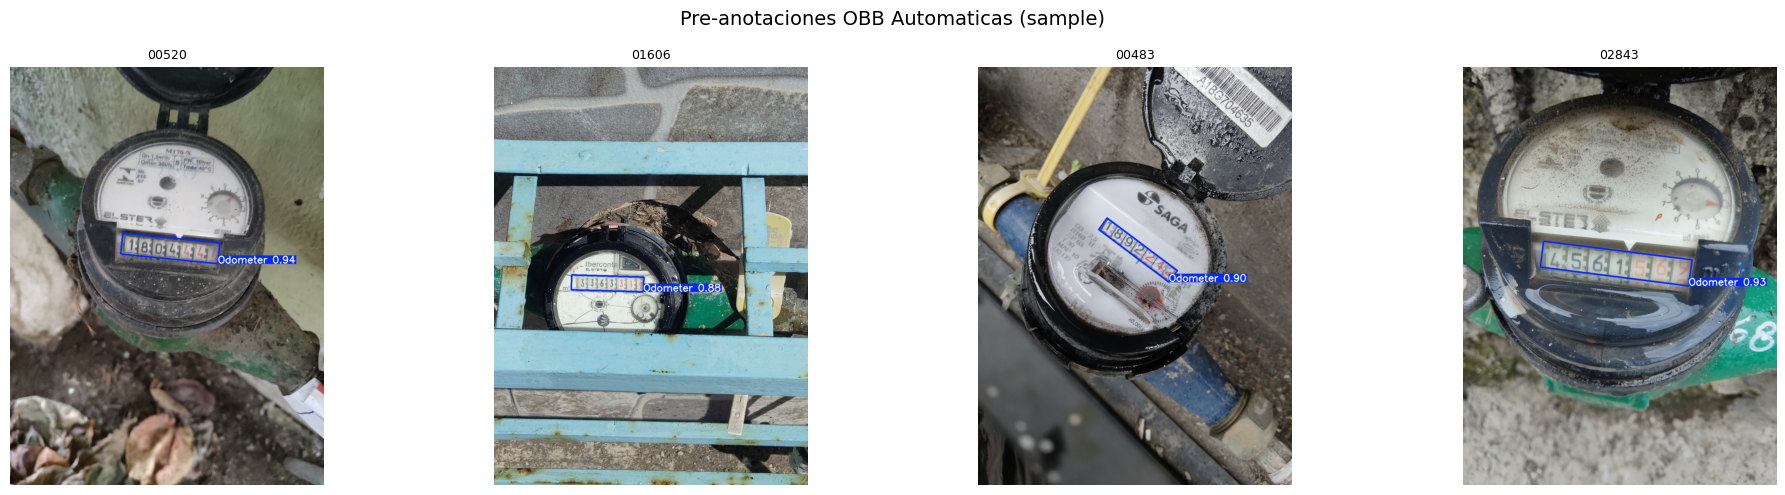

In [30]:
viz_files = [f for f in os.listdir(AUTO_VIZ_PATH) if f.endswith('_annotated.jpg')]
if viz_files:
    samples = random.sample(viz_files, min(4, len(viz_files)))

    fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5))
    if len(samples) == 1:
        axes = [axes]

    for idx, viz_file in enumerate(samples):
        img = cv2.imread(f'{AUTO_VIZ_PATH}/{viz_file}')
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(img)
        axes[idx].set_title(viz_file.replace('_annotated.jpg', ''), fontsize=9)
        axes[idx].axis('off')

    plt.suptitle('Pre-anotaciones OBB Automaticas (sample)', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No hay previews generados")

---

## PARTE 7: EXPORTAR Y RESUMEN

### 7.1 Comprimir Anotaciones para CVAT

In [31]:
zip_path = f'{AUTO_LABELS_DIR}/auto_annotations.zip'

if os.path.exists(AUTO_LABELS_PATH):
    label_files = [f for f in os.listdir(AUTO_LABELS_PATH) if f.endswith('.txt')]

    if label_files:
        with zipfile.ZipFile(zip_path, 'w') as zipf:
            for label_file in label_files:
                zipf.write(f'{AUTO_LABELS_PATH}/{label_file}', arcname=label_file)

        print(f"ZIP creado: {zip_path}")
        print(f"  Archivos: {len(label_files)}")
        print(f"  Tamaño: {os.path.getsize(zip_path) / 1024:.1f} KB")
    else:
        print("No hay anotaciones para comprimir")
else:
    print("Ejecutar pre-anotacion primero")

ZIP creado: /content/drive/MyDrive/water-meter-training/auto-annotator/auto-annotated/auto_annotations.zip
  Archivos: 844
  Tamaño: 139.4 KB


### 7.2 Exportar Modelo

Guarda `best.pt` y `training_config.yaml` en `export/` para respaldo.

In [34]:
if RUN_PATH:
    EXPORT_DIR = f'{COMPONENT_DIR}/export'
    if os.path.exists(EXPORT_DIR):
        shutil.rmtree(EXPORT_DIR)
    os.makedirs(EXPORT_DIR)
    metrics_dir = f'{EXPORT_DIR}/metrics'
    os.makedirs(metrics_dir)

    # Copiar best.pt
    best_src = f'{RUN_PATH}/weights/best.pt'
    if os.path.exists(best_src):
        shutil.copy(best_src, f'{EXPORT_DIR}/best.pt')
        print("Copiado: best.pt")

    # Copiar métricas
    metric_files = [
        'results.png', 'results.csv', 'args.yaml',
        'confusion_matrix.png', 'confusion_matrix_normalized.png',
        'BoxPR_curve.png', 'BoxF1_curve.png',
    ]
    copied = 0
    for fname in metric_files:
        src = f'{RUN_PATH}/{fname}'
        if os.path.exists(src):
            shutil.copy(src, f'{metrics_dir}/{fname}')
            copied += 1
    print(f"Copiados {copied} archivos a metrics/")

    # Generar training_config.yaml
    training_config = {
        'model': {'weights': MODEL_NAME},
        'training': {
            'epochs': EPOCHS,
            'img_size': IMG_SIZE,
            'batch_size': BATCH_SIZE,
            'patience': PATIENCE,
        },
        'dataset': {
            'source': 'data/obb-seed',
            'train_images': count_images(TRAIN_IMAGES),
            'val_images': count_images(VAL_IMAGES),
        },
        'metadata': {
            'exported_on': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'purpose': 'Pre-anotacion OBB para CVAT',
        },
    }
    if 'metrics' in dir() and metrics is not None:
        training_config['metrics'] = {
            'mAP50-95': round(float(metrics.box.map), 4),
            'mAP50': round(float(metrics.box.map50), 4),
            'precision': round(float(metrics.box.mp), 4),
            'recall': round(float(metrics.box.mr), 4),
        }

    with open(f'{EXPORT_DIR}/training_config.yaml', 'w') as f:
        yaml.dump(training_config, f, default_flow_style=False, sort_keys=False)
    print("Generado: training_config.yaml")

    print(f"\nExport listo: {EXPORT_DIR}")
    for root, dirs, files in os.walk(EXPORT_DIR):
        level = root.replace(EXPORT_DIR, '').count(os.sep)
        indent = '  ' * level
        folder = os.path.basename(root)
        if level > 0:
            print(f"{indent}{folder}/")
        for f in sorted(files):
            print(f"{indent}  {f}")
else:
    print("No hay corrida para exportar")

Copiado: best.pt
Copiados 7 archivos a metrics/
Generado: training_config.yaml

Export listo: /content/drive/MyDrive/water-meter-training/auto-annotator/export
  best.pt
  training_config.yaml
  metrics/
    BoxF1_curve.png
    BoxPR_curve.png
    args.yaml
    confusion_matrix.png
    confusion_matrix_normalized.png
    results.csv
    results.png


In [33]:
RUN_PATH

'/content/drive/MyDrive/water-meter-training/auto-annotator/runs/auto-annotator'

### 7.3 Siguientes Pasos

1. **Descargar** `auto-annotated/auto_annotations.zip` desde Drive
2. **Importar a CVAT** en formato YOLO OBB
3. **Revisar y corregir** bounding boxes manualmente
4. **Exportar dataset final** → se convierte en `data/annotations/obb/`
5. **Entrenar detector de odómetro** con el dataset completo (notebook `03_train_odometer_detector.ipynb`)